ACROSS-PARTICIPANT RSA

ISPC: correlates each participant's voxel pattern for each event with the group mean pattern for that event (excluding themselves)
separately for moral and non-moral sentences
average across left and right hemisphere
paired t test


In [1]:
import os
import numpy as np
from nilearn import image
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr, zscore, ttest_rel, pearsonr, ttest_ind
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
import seaborn as sns
from scipy.stats import sem
from scipy.signal import detrend


In [2]:
foundationScores_dir = "/Users/silvycollin/Documents/GitHub/wholeBrain_narratives_MAC_MFT/text/foundationScores/"

whichFoundationScore = "MAC_a_moral_nonmoral"

In [16]:
whichVersion = 'persentence' #persentence, 3sec, 6sec

# save
save_dir = os.path.expanduser(
    "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/RSA/"
)

groupSplit_dir = os.path.expanduser(
        "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/"
    )

In [4]:
# ------------------------
# Load 
# ------------------------

whichROI = "hippocampus" # hippocampus,STG_MTG_refined_mask,TPJ_refined_mask

whichStory = "shapessocial"  # shapessocial, shapesphysical, prettymouthaffair,prettymouthparanoia,

base_dir = os.path.expanduser(
    "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/processed_first_level_per_sentence/"
)

if whichVersion =='persentence':
    foundationScores_file = f"{foundationScores_dir}{whichStory}_MFT_MAC.xlsx"
    foundationScores = pd.read_excel(foundationScores_file)
elif whichVersion =='3sec':
    foundationScores_file = f"{foundationScores_dir}{whichStory}_3_seconds_MFT_MAC.xlsx"
    foundationScores = pd.read_excel(foundationScores_file)
elif whichVersion =='6sec':
    foundationScores_file = f"{foundationScores_dir}{whichStory}_6_seconds_MFT_MAC.xlsx"
    foundationScores = pd.read_excel(foundationScores_file)

print(whichStory)
print(whichROI)

data_dir = f"{base_dir}{whichStory}/"

left = np.load(data_dir + f"{whichStory}_{whichROI}_L_3D_clean.npy")
right = np.load(data_dir + f"{whichStory}_{whichROI}_R_3D_clean.npy")

if whichStory == 'shapesphysical':
    left = left[:, :306, :]
    right = right[:, :306, :]

shapessocial
hippocampus


In [5]:
foundationScores['end']

0       3.175
1       5.858
2      10.544
3      13.448
4      16.992
       ...   
82    438.510
83    439.872
84    441.755
85    444.980
86    452.352
Name: end, Length: 87, dtype: float64

In [6]:
(foundationScores['end'] / 1.5) + 3

0       5.116667
1       6.905333
2      10.029333
3      11.965333
4      14.328000
         ...    
82    295.340000
83    296.248000
84    297.503333
85    299.653333
86    304.568000
Name: end, Length: 87, dtype: float64

In [7]:
left[:,:200,6]

array([[ 0.673754  ,  1.52396572,  1.61923718, ...,  1.63375058,
        -1.8281324 , -0.12465143],
       [ 3.19999037, -0.30310386,  0.90025368, ..., -3.12221274,
        -0.84473896, -0.69867015],
       [ 0.36435299, -0.80936131,  0.00732494, ..., -1.31646042,
        -0.1499148 ,  0.5061692 ],
       ...,
       [ 1.94420389,  1.70719646,  2.73331038, ..., -1.28983793,
         1.29884167,  1.09499144],
       [ 1.35670938,  1.48284542,  1.74559972, ...,  1.29220187,
        -0.96763839,  2.03207149],
       [ 0.60356521,  1.56585228,  1.16536901, ...,  0.38425341,
        -0.09656527, -0.04110293]])

In [8]:
left.shape

(691, 309, 58)

In [9]:
meanData = np.mean(left,axis=0)
meanData.shape

(309, 58)

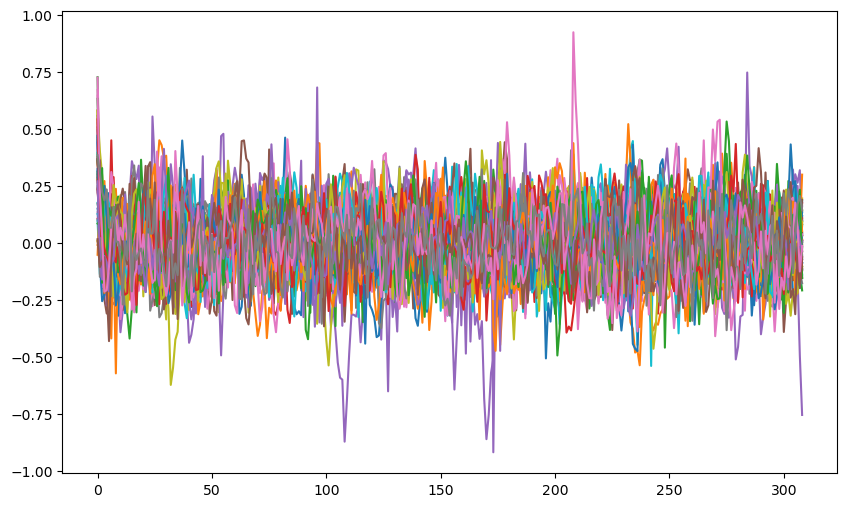

In [10]:
x = np.arange(meanData.shape[0])
plt.figure(figsize=(10, 6))
for i in range(meanData.shape[1]):   # loop over 58 columns
    plt.plot(x, meanData[:, i])

(309,)


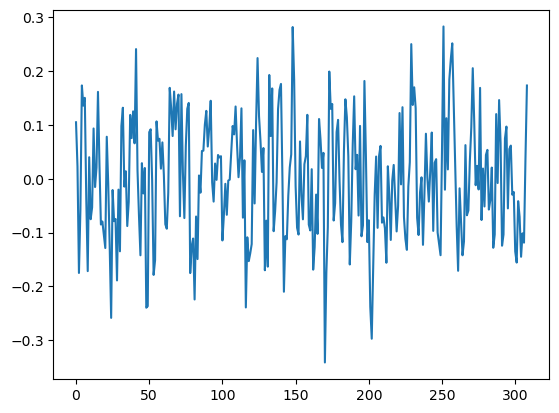

In [11]:
plt.plot(x, meanData[:, 3])
print(meanData[:, 3].shape)

In [12]:
# ------------------------
# load foundation scores 
# ------------------------
# start and end column is start and end of the sentences in seconds, TR was 1.5 sec

foundationScoresSelect = foundationScores[[whichFoundationScore,"start","end"]]
foundationScoresSelect = foundationScoresSelect.copy()

# go from seconds to TRs for start and end column
foundationScoresSelect["startTR"] = foundationScoresSelect["start"] / 1.5
foundationScoresSelect["endTR"] = foundationScoresSelect["end"] / 1.5

# round to full TRs/volumes
foundationScoresSelect["startTR"] = foundationScoresSelect["startTR"].round(0).astype(int)
foundationScoresSelect["endTR"] = foundationScoresSelect["endTR"].round(0).astype(int)

# shift by 3 TRs for the HRF
foundationScoresSelect['startTR'] = foundationScoresSelect['startTR'] + 3
foundationScoresSelect['endTR'] = foundationScoresSelect['endTR'] + 3


In [13]:
# split into the moral vs non moral sentences
foundationScoresSelect_nonzero = foundationScoresSelect[foundationScoresSelect[whichFoundationScore] != 0]

foundationScoresSelect_zero = foundationScoresSelect[foundationScoresSelect[whichFoundationScore] == 0]


Running ISPC for LEFT hemisphere...
Running ISPC for RIGHT hemisphere...

Participant-level ISPC results
t = 3.72, p = 0.0005


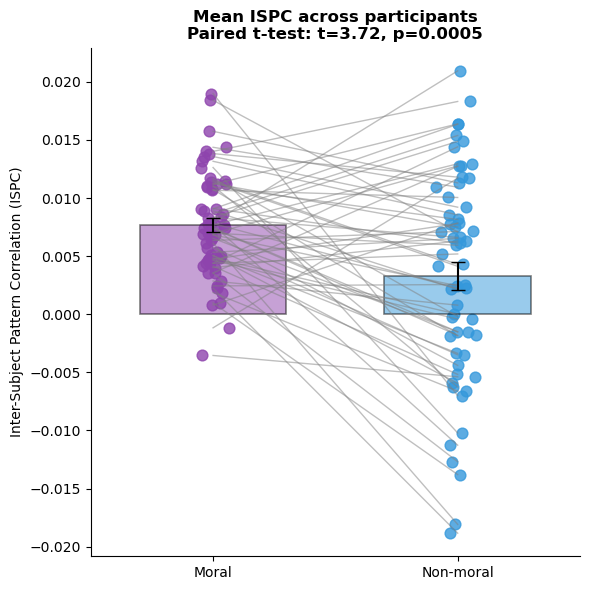

In [14]:

# ================================================================
# Function: Inter-Subject Pattern Correlation (ISPC)
# ================================================================
def run_inter_subject_pattern_correlation(data_array, events):
    """
    Compute inter-subject pattern correlation (ISPC) for each event
    and return the average ISPC per participant.
    
    data_array : np.ndarray
        Shape (voxels x TRs x participants)
    events : pd.DataFrame
        Columns ['startTR', 'endTR']
    
    Returns
    -------
    ispc_per_participant : np.ndarray
        Mean ISPC per participant across all events.
    """
    # Clean and prepare events
    events = events.dropna(subset=['startTR', 'endTR']).sort_values('startTR').reset_index(drop=True)
    events['startTR'] = events['startTR'].astype(int)
    events['endTR'] = events['endTR'].astype(int)
    n_events = len(events)
    n_vox, n_tr, n_part = data_array.shape

    # Z-score each participant voxelwise over time
    data_z = np.zeros_like(data_array)
    for p in range(n_part):
    #    print('participant; ',p)
        data_z[:, :, p] = zscore(data_array[:, :, p], axis=1, ddof=1)
    #    print(np.mean(data_z))

    # Compute mean spatial pattern per event per participant
    event_patterns = np.zeros((n_vox, n_events, n_part))
    for i, ev in events.iterrows():
        start_tr = int(ev['startTR'])
        end_tr = int(ev['endTR'])
        event_patterns[:, i, :] = np.mean(data_z[:, start_tr:end_tr + 1, :], axis=1)

    # Compute ISPC (inter-subject pattern correlation)
    ispc_per_participant = np.zeros(n_part)
    for p in range(n_part):
        others = np.delete(np.arange(n_part), p)
        corrs = []
        for i in range(n_events):
            this_pattern = event_patterns[:, i, p]
            others_mean = np.mean(event_patterns[:, i, others], axis=1)
            
            # nan_indices = np.argwhere(np.isnan(others_mean))
            # print('shape ', others_mean.shape)
            # print(nan_indices)
            
            r, _ = pearsonr(this_pattern, others_mean)
            corrs.append(r)
        ispc_per_participant[p] = np.mean(corrs)
    
    return ispc_per_participant


# ================================================================
# Run ISPC for both hemispheres (moral and non-moral)
# ================================================================
print("Running ISPC for LEFT hemisphere...")
ispc_moral_part_L = run_inter_subject_pattern_correlation(left, foundationScoresSelect_nonzero)
ispc_nonmoral_part_L = run_inter_subject_pattern_correlation(left, foundationScoresSelect_zero)

print("Running ISPC for RIGHT hemisphere...")
ispc_moral_part_R = run_inter_subject_pattern_correlation(right, foundationScoresSelect_nonzero)
ispc_nonmoral_part_R = run_inter_subject_pattern_correlation(right, foundationScoresSelect_zero)


# ================================================================
# Average across hemispheres (participant-level)
# ================================================================
# n_participants = min(len(ispc_moral_part_L), len(ispc_moral_part_R),
#                      len(ispc_nonmoral_part_L), len(ispc_nonmoral_part_R))

# ispc_moral_part_avg = (ispc_moral_part_L[:n_participants] + ispc_moral_part_R[:n_participants]) / 2
# ispc_nonmoral_part_avg = (ispc_nonmoral_part_L[:n_participants] + ispc_nonmoral_part_R[:n_participants]) / 2


ispc_moral_part_avg = (ispc_moral_part_L + ispc_moral_part_R) / 2
ispc_nonmoral_part_avg = (ispc_nonmoral_part_L + ispc_nonmoral_part_R) / 2


# ================================================================
# Paired t-test
# ================================================================
tval, pval = ttest_rel(ispc_moral_part_avg, ispc_nonmoral_part_avg)
print("\n===============================")
print("Participant-level ISPC results")
print("===============================")
print(f"t = {tval:.2f}, p = {pval:.4f}")


# ================================================================
# Visualization
# ================================================================
fig, ax = plt.subplots(figsize=(6, 6))
x_pos = [0, 1]
colors = ['#8E44AD', '#3498DB'] 

# Connect lines per participant
for i in range(len(ispc_moral_part_L)):
    ax.plot(x_pos,
            [ispc_moral_part_avg[i], ispc_nonmoral_part_avg[i]],
            color='gray', alpha=0.5, linewidth=1)

# Add jittered dots
ax.scatter(np.zeros(len(ispc_moral_part_L)) + np.random.normal(0, 0.03, len(ispc_moral_part_L)),
            ispc_moral_part_avg,
            color=colors[0], s=60, alpha=0.8, label='Moral')

ax.scatter(np.ones(len(ispc_moral_part_L)) + np.random.normal(0, 0.03, len(ispc_moral_part_L)),
            ispc_nonmoral_part_avg,
            color=colors[1], s=60, alpha=0.8, label='Non-moral')

# Mean + SEM bars
mean_vals = [np.mean(ispc_moral_part_avg), np.mean(ispc_nonmoral_part_avg)]
sem_vals = [np.std(ispc_moral_part_avg)/np.sqrt(len(ispc_moral_part_L)),
            np.std(ispc_nonmoral_part_avg)/np.sqrt(len(ispc_moral_part_L))]
ax.bar(x_pos, mean_vals, yerr=sem_vals, color=colors, alpha=0.5, width=0.6,
       capsize=5, edgecolor='black', linewidth=1.2)

# Aesthetics
ax.set_xticks(x_pos)
ax.set_xticklabels(['Moral', 'Non-moral'])
ax.set_ylabel('Inter-Subject Pattern Correlation (ISPC)')
ax.set_title(f'Mean ISPC across participants\nPaired t-test: t={tval:.2f}, p={pval:.4f}',
             fontsize=12, weight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(-0.5, 1.5)
plt.tight_layout()
plt.savefig(str(save_dir)+f"MoralNonmoral_{whichROI}_{whichStory}_{whichVersion}_acrossParticipants.png", dpi=300)
plt.show()


# group split directory

In [17]:


TaskOrder = pd.read_csv(groupSplit_dir+'NarrativesParticipants.csv')
TaskOrder = TaskOrder[['BIDS ID','Notes','Manipulation']]
TaskOrder = TaskOrder.dropna(how='all')
# remove duplicate rows, only 1 row per participant
TaskOrder = TaskOrder[TaskOrder['Manipulation'] == 'social']
